In [1]:
def F(X,y,f,theta):
    total_loss = 0
    for i in range(N):
        total_loss += loss(f(X[i,:],theta),y[i])
    return total_loss

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from idlmam import *
from tqdm.autonotebook import tqdm

import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

import pandas as pd

import time

In [54]:
def train_simple_network(model, loss_func, training_loader, epochs=100, device="cpu"):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    model.to(device)

    for epoch in tqdm(range(epochs), desc="Epoch"):
    
        model = model.train()#Put our model in training mode
        running_loss = 0.0

        for inputs, labels in tqdm(training_loader, desc="Batch", leave=False):
            inputs = moveTo(inputs, device)
            labels = moveTo(labels, device)

            optimizer.zero_grad()
            y_hat = model(inputs)

            loss = loss_func(y_hat, labels)
            loss.backward()
            

            optimizer.step()
            running_loss += loss.item()
            

<Axes: >

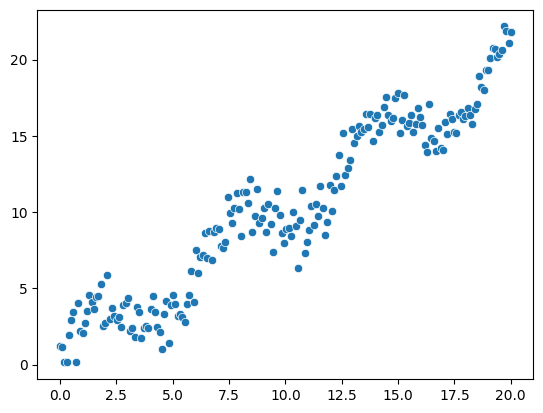

In [55]:
X = np.linspace(0,20,num=200)
y = X +np.sin(X)*2 + np.random.normal(size=X.shape)
sns.scatterplot(x=X,y=y)

In [56]:
class Simple1DRegresionDataset(Dataset):
    def __init__(self,X,y):
        super(Simple1DRegresionDataset).__init__()
        self.X =X.reshape(-1,1)
        self.y = y.reshape(-1,1)
        
    def __getitem__(self, index):
        return torch.tensor(self.X[index,:],dtype=torch.float32),torch.tensor(self.y[index],dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

training_loader = DataLoader(Simple1DRegresionDataset(X,y),shuffle=True)

In [57]:
in_features =1
out_features = 1
model = nn.Linear(in_features,out_features)
loss_func = nn.MSELoss()
device = torch.device("cuda")
train_simple_network(model, loss_func, training_loader, device=device )

Epoch: 100%|██████████| 100/100 [00:15<00:00,  6.57it/s]


<Axes: >

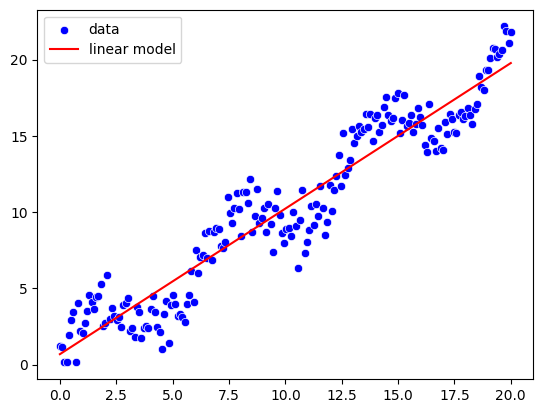

In [58]:
with torch.no_grad():
    Y_pred =model(torch.tensor(X.reshape(-1,1),device=device,dtype=torch.float32)).cpu().numpy()
sns.scatterplot(x=X,y=y,color="blue",label="data")
sns.lineplot(x=X,y=Y_pred.ravel(),color="red",label="linear model")

In [60]:
model = nn.Sequential(
    nn.Linear(1,10),
    nn.Linear(10,1),
)
train_simple_network(model,loss_func,training_loader)

Epoch: 100%|██████████| 100/100 [00:06<00:00, 14.90it/s]


<Axes: >

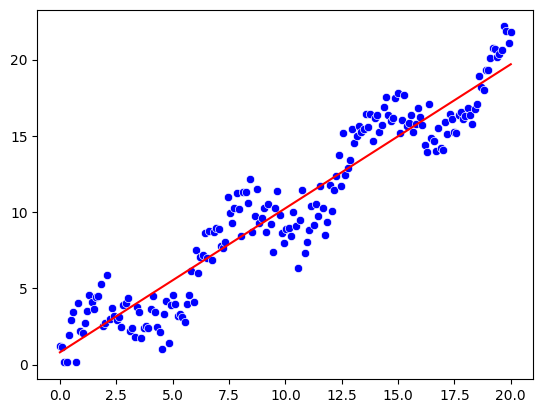

In [62]:
with torch.no_grad():
    Y_pred = model(torch.tensor(X.reshape(-1,1),dtype=torch.float32)).cpu().numpy()

sns.scatterplot(x=X,y=y,color="b")
sns.lineplot(x=X,y=Y_pred.ravel(),color="r")

Text(0, 0.5, 'Activation')

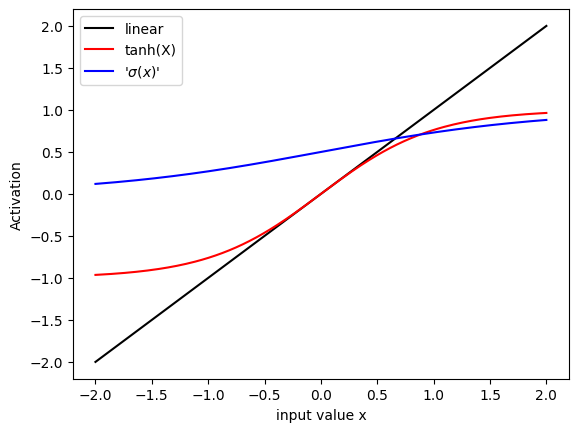

In [66]:
activation_input = np.linspace(-2,2,num=200)
tanh_activation = np.tanh(activation_input)
sigmoid_activation = np.exp(activation_input)/(np.exp(activation_input)+1)
sns.lineplot(x=activation_input,y=activation_input,color="black",label="linear")
sns.lineplot(x=activation_input,y=tanh_activation,color="red",label="tanh(X)")
ax=sns.lineplot(x=activation_input,y=sigmoid_activation,color="blue",label="'$σ(x)$'")
ax.set_xlabel('input value x')
ax.set_ylabel("Activation")


In [69]:
model =nn.Sequential(
    nn.Linear(1,10),
    nn.Tanh(),
    nn.Linear(10,1),
)

train_simple_network(model,loss_func,training_loader,epochs=200)

Epoch: 100%|██████████| 200/200 [00:18<00:00, 10.97it/s]


<Axes: >

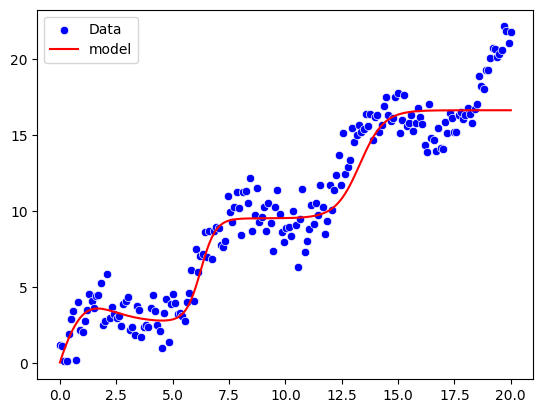

In [70]:
with torch.no_grad():
    Y_pred =model(torch.tensor(X.reshape(-1,1),dtype=torch.float32)).cpu().numpy()
sns.scatterplot(x=X,y=y,color="b",label="Data")
sns.lineplot(x=X,y=Y_pred.ravel(),color="r",label="model")